In [425]:
import uproot
import matplotlib.pyplot as plt
import numpy as np
import os
import boost_histogram as bh
from particle_utils import get_charge_from_pdgc, get_name_from_pdgc
from tqdm import tqdm
import awkward as ak
from collections.abc import Sequence
import matplotlib.ticker as plticker
from copy import deepcopy
from functools import partial


In [426]:
lumi_sf = 3000/40800 # Rescale to 3 fb^-1
density_sf = 0.1786/1.2929
he_sf = density_sf * lumi_sf
air_sf = lumi_sf

print(air_sf)
print(f"Density ratio: {density_sf:.2f}")

0.07352941176470588
Density ratio: 0.14


In [427]:
data = uproot.open("../../GeantOutput/AirDv40800.root:Hits")
events = data.arrays(data.keys())

In [428]:
class NuDataSet(Sequence):
    
    def __init__(self, name, events, hits_mask=None, latex_name=None, colour=None):
        self.name = name
        self.events = events
        self.hits_mask = hits_mask
        self.latex_name = latex_name if latex_name is not None else name
        self.colour = colour
    
    def __getitem__(self, i):
        return self.events[i]
    
    def __len__(self):
        return len(self.events)

In [429]:
def vertex_cut(events, x1=-1500, x2=1500, y1=-500, y2=500, z1=0, z2=10000):
    return events[(x1 < events['vertex_x']) &  
                  (events['vertex_x'] < x2) & 
                  (y1 < events['vertex_y']) &
                  (events['vertex_y'] < y2) &
                  (z1 < events['vertex_z']) &
                  (events['vertex_z']< z2)]

In [519]:
def compute_masks(events, energy_threshold=None, nhits=None):
    masks = []
    
    #* Require hits which are within nominal 3 x 1 m tracking window, are charged 
    #* and are in the final tracking layer (this approximates requirement for hits in all layers)
    
    for event in events:
        mask = []

        n = 0
        for x, y, layer, pdgc, energy in zip(event['x'], event['y'], event['layer'], event['pdgc'], event['E']):
            if -1500 < x < 1500 and -500 < y < 500 and get_charge_from_pdgc(pdgc) != 0 and layer == 5:
                
                if energy_threshold is not None and energy < energy_threshold:
                    mask.append(False)    
                else:
                    mask.append(True)
                    n += 1
            else:
                mask.append(False)
        
        # Mask all entries if they do not have exactly nhits
        if nhits is not None and n != nhits:
            mask = [False if value else value for value in mask]
        masks.append(mask)
    
    return ak.Array(masks)    

In [520]:
nc_data     = NuDataSet("Neutral Current", vertex_cut(events[events['isCC'] == False]), latex_name="NC", colour="green")
cc_el_data  = NuDataSet("Charged Current Electron", vertex_cut(events[(abs(events['nu_pdgc']) == 12) & (events['isCC'] == True)]), latex_name=r"CC $\nu_e$", colour="lightblue")
cc_mu_data  = NuDataSet("Charged Current Muon", vertex_cut(events[(abs(events['nu_pdgc']) == 14) & (events['isCC'] == True)]), latex_name=r"CC $\nu_\mu$", colour="orange")
cc_tau_data = NuDataSet("Charged Current Tau", vertex_cut(events[(abs(events['nu_pdgc']) == 16) & (events['isCC'] == True)]), latex_name=r"CC $\nu_\tau$", colour="purple")

nc_data.hits_mask = compute_masks(nc_data.events)
cc_el_data.hits_mask = compute_masks(cc_el_data.events) 
cc_mu_data.hits_mask = compute_masks(cc_mu_data.events) 
cc_tau_data.hits_mask = compute_masks(cc_tau_data.events) 

datasets = [nc_data, cc_mu_data, cc_el_data, cc_tau_data]

In [431]:
print("------ Raw ------")
print(f"NC = {len(nc_data):.1f}")
print(f"CC el = {len(cc_el_data):.1f}")
print(f"CC mu = {len(cc_mu_data):.1f}")
print(f"CC tau = {len(cc_tau_data) :.1f}")
print(f"Total = {(len(nc_data)+len(cc_el_data)+len(cc_mu_data)+len(cc_tau_data)):.1f}")

------ Raw ------
NC = 2334.0
CC el = 1199.0
CC mu = 5811.0
CC tau = 56.0
Total = 9400.0


In [432]:
print("------ Air ------")
print(f"NC = {len(nc_data) * air_sf:.1f}")
print(f"CC el = {len(cc_el_data) * air_sf:.1f}")
print(f"CC mu = {len(cc_mu_data) * air_sf:.1f}")
print(f"CC tau = {len(cc_tau_data) * air_sf:.1f}")
print(f"Total = {(len(nc_data)+len(cc_el_data)+len(cc_mu_data)+len(cc_tau_data))*air_sf:.1f}")

------ Air ------
NC = 171.6
CC el = 88.2
CC mu = 427.3
CC tau = 4.1
Total = 691.2


In [433]:
print("------ Helium ------")
print(f"NC = {len(nc_data) * he_sf:.1f}")
print(f"CC el = {len(cc_el_data) * he_sf:.1f}")
print(f"CC mu = {len(cc_mu_data) * he_sf:.1f}")
print(f"CC tau = {len(cc_tau_data) * he_sf:.1f}")
print(f"Total = {(len(nc_data)+len(cc_el_data)+len(cc_mu_data)+len(cc_tau_data))*he_sf:.1f}")

------ Helium ------
NC = 23.7
CC el = 12.2
CC mu = 59.0
CC tau = 0.6
Total = 95.5


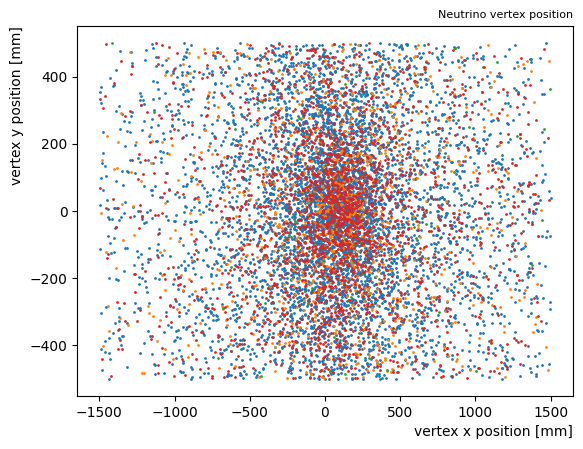

In [434]:
fig, ax = plt.subplots()
ax.scatter(cc_mu_data['vertex_x'], cc_mu_data['vertex_y'], s=1);
ax.scatter(cc_el_data['vertex_x'], cc_el_data['vertex_y'], s=1);
ax.scatter(cc_tau_data['vertex_x'], cc_tau_data['vertex_y'], s=1);
ax.scatter(nc_data['vertex_x'], nc_data['vertex_y'], s=1);
ax.set_xlabel("vertex x position [mm]", loc='right')
ax.set_ylabel("vertex y position [mm]", loc='top')
ax.set_title("Neutrino vertex position", loc='right', fontsize=8)
plt.savefig("HeDv-vertex-scatter.pdf")

In [504]:
def fill_hits_histogram(histogram, dataset, variable=None, func=None, cut=None, fill_zero=False):
    c = 0
    for i, event in enumerate(dataset):
        try:
            if cut is not None:
                event = cut(event)
            if func is not None:
                if variable is None:
                    val = func(event, dataset.hits_mask[i])
                else:    
                    val = func(event[variable][dataset.hits_mask[i]])
                
                if val == 0 and not fill_zero: continue
                histogram.fill(val)
            else:
                val = event[variable][dataset.hits_mask[i]]
                if val < 10:
                        print(val, event[variable], dataset.hits_mask[i])
                # if val == 0 and not fill_zero: continue
                # print(get_name_from_pdgc(val), get_charge_from_pdgc(val))
                # print(val)
                histogram.fill(val)
            c = c + 1
        except Exception as e:
            # print(e)
            pass
    
    
    print(dataset.name, c)
    return histogram

In [438]:
def plot_stacked_hist(datasets, variable, bins, names=None, colours=None, function=None, scale_factor=1, xlabel="variable", ylabel='events', title_right="", title_left="", xrange=None, saveas=None, fill_zero=False):
    
    histograms = [bh.Histogram(bh.axis.Regular(bins[0], bins[1], bins[2], overflow=True)) for _ in datasets]

    histograms = [fill_hits_histogram(hist, dataset, variable, func=function, fill_zero=fill_zero) for hist, dataset in zip(histograms, datasets)]
    
    if names is None:
        names = [dataset.latex_name for dataset in datasets]    
    if colours is None:
        colours = [dataset.colour for dataset in datasets] 
    
    total_hist_sizes = [sum(h.view(flow=True)) for h in histograms]
    combined_args = list(zip(total_hist_sizes, histograms, names, colours))
    sorted_combined_args = sorted(combined_args)
    total_hist_size, histograms, names, colours = zip(*sorted_combined_args)
    
    bin_edges = histograms[0].axes[0].edges
    bin_centers = histograms[0].axes[0].centers
    bin_width = bin_edges[1] - bin_edges[0]

    stacked_counts = np.stack([h.view(flow=True) for h in histograms])
    uncertainties = np.sqrt(stacked_counts)
    stacked_counts *= scale_factor
    total = sum(total_hist_sizes) * scale_factor

    # print(f"Total number of histogram entries: {total:.1f}")
    fig, ax = plt.subplots()
    sum_values = np.zeros_like(bin_centers)
    for i, (histogram, name, colour) in enumerate(zip(histograms, names, colours)):
        values = stacked_counts[i]
        values[1] += values[0]
        values[-2] += values[-1]
        if i == 0:
            ax.bar(bin_centers, values[1:-1], width=bin_width, label=name, color=colour)
        else:
            bottom_values = stacked_counts[i-1]
            bottom_values[1] += bottom_values[0]
            bottom_values[-2] += bottom_values[-1]       
            ax.bar(bin_centers, values[1:-1], width=bin_width, bottom=sum_values, label=name, color=colour)
            
        
        sum_values += values[1:-1]    
    
    total_stacked_counts = np.sum(stacked_counts, axis=0)
    
    total_uncertainties = np.sqrt(np.sum(uncertainties**2, axis=0))
    total_stacked_counts[1] += total_stacked_counts[0]
    total_stacked_counts[-2] += total_stacked_counts[-1]
    total_stacked_counts = total_stacked_counts[1:-1]
    
    total_uncertainties[1] = np.sqrt(total_uncertainties[0]**2 + total_uncertainties[1]**2)
    total_uncertainties[-2] = np.sqrt(total_uncertainties[-1]**2 + total_uncertainties[-2]**2)
    total_uncertainties = total_uncertainties[1:-1]*scale_factor
    
    for i, (count, unc) in enumerate(zip(sum_values, total_uncertainties)):
        ax.fill_between(bin_edges[i:i+2], count-unc, count+unc, color='gray', alpha=0.3, label='Stat. Error', edgecolor=None, hatch="//")

    ax.set_xlabel(xlabel, loc='right')    
    ax.set_ylabel(ylabel, loc='top')
    ax.tick_params(axis='both', which='both', direction='in')
    ax.set_title(title_right, loc='right', fontsize=8)
    ax.set_title(f'{title_left}', loc='left', fontsize=8)
    if xrange is not None:
        ax.set_xlim(xrange)
    handles, labels = ax.get_legend_handles_labels()
    unique_labels = dict(zip(labels, handles))
    ax.legend(unique_labels.values(), unique_labels.keys())
    
    if saveas is not None:
        plt.savefig(saveas)
        
    plt.show()

Neutral Current 2334
Charged Current Muon 5811
Charged Current Electron 1199
Charged Current Tau 56


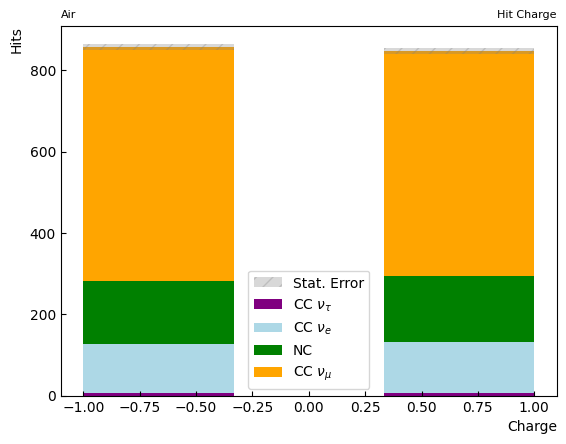

In [439]:

plot_stacked_hist(datasets, "charge", (3, -1, 1), fill_zero=True,
                  scale_factor=air_sf, xlabel=r"Charge", ylabel="Hits",
                  title_left="Air", title_right="Hit Charge", saveas="AirDV-charge.svg"
                  )

Neutral Current 1366
Charged Current Muon 5061
Charged Current Electron 1101
Charged Current Tau 49


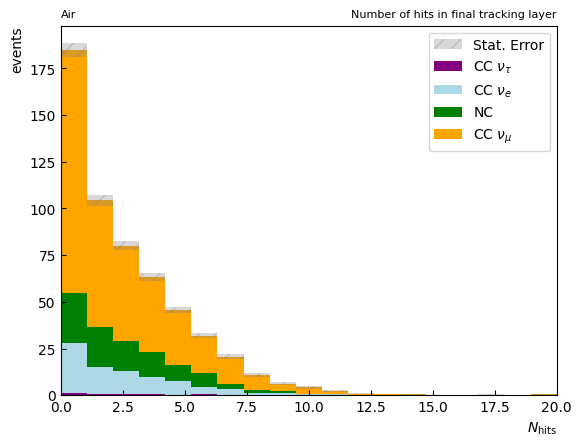

In [521]:

plot_stacked_hist(datasets, "x", (19, 0, 20), function=len,
                  scale_factor=air_sf, xlabel=r"$N_\text{hits}$", 
                  title_left="Air", title_right="Number of hits in final tracking layer",
                  xrange=[0, 20], saveas="AirDV-nHitsStation5.svg"
                  )

Neutral Current 2334
Charged Current Muon 5811
Charged Current Electron 1199
Charged Current Tau 56


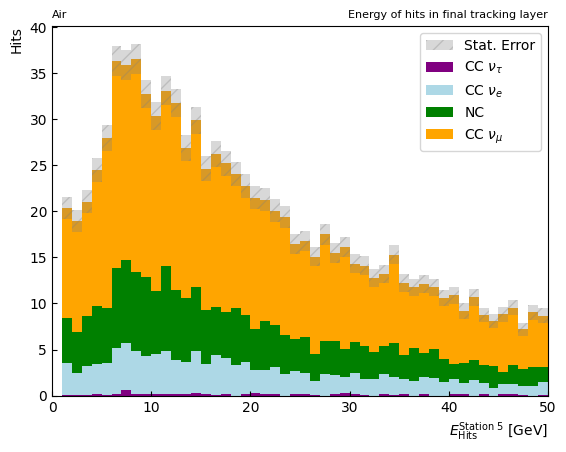

In [488]:
plot_stacked_hist(datasets, "E", (2000, 0, 2000),
                  scale_factor=air_sf, xlabel=r"$E_\text{Hits}^\text{Station 5}$ [GeV]", ylabel="Hits",
                  title_left="Air", title_right="Energy of hits in final tracking layer", saveas="AirDV-HitEnergyStation5.svg",
                  xrange=[0, 50]
                  )

Neutral Current 1366
Charged Current Muon 5061
Charged Current Electron 1101
Charged Current Tau 49


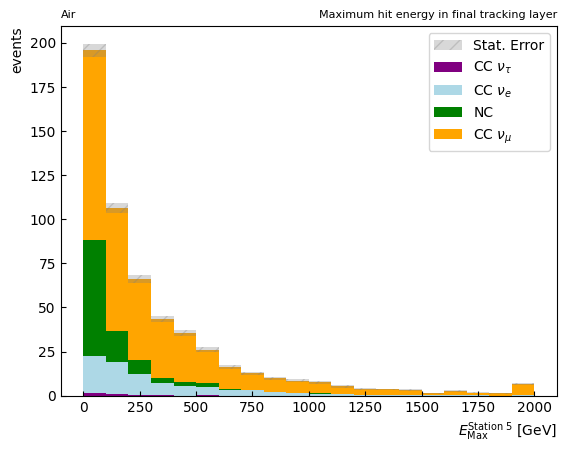

In [442]:
plot_stacked_hist(datasets, "E", (20, 0, 2000), function=max,
                  scale_factor=air_sf, xlabel=r"$E_\text{Max}^\text{Station 5}$ [GeV]", 
                  title_left="Air", title_right="Maximum hit energy in final tracking layer",
                  saveas="AirDV-MaxHitEnergyStation5.svg"
                  )

In [522]:
datasets_10GeV_thresh = deepcopy(datasets)
for i in range(len(datasets_10GeV_thresh)):
    mask = compute_masks(datasets_10GeV_thresh[i].events, energy_threshold=10)
    datasets_10GeV_thresh[i].mask = mask

Neutral Current 1366
Charged Current Muon 5061
Charged Current Electron 1101
Charged Current Tau 49


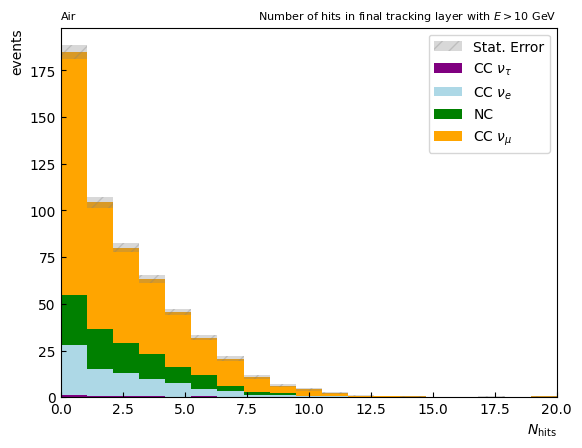

In [523]:
plot_stacked_hist(datasets_10GeV_thresh, "x", (19, 0, 20), function=len,
                  scale_factor=air_sf, xlabel=r"$N_\text{hits}$", 
                  title_left="Air", title_right="Number of hits in final tracking layer with $E > 10$ GeV",
                  xrange=[0, 20], saveas="AirDV-nHitsAbove10GeVStation5.svg"
                  )

[7.23] [3.83, 6.39, 18.6, 2.82, 7.23, 48.5, ..., 2.82, 7.23, 48.5, 1.86, 13.1, 23.2] [False, False, False, False, False, ..., True, False, False, False, False]
[4.87] [3.1, 5.38, 1.17, 47.6, 3.1, 5.38, 1.17, ..., 1.17, 47.6, 3.1, 4.87, 1.17, 47.6] [False, False, False, False, False, ..., False, False, True, False, False]
[4.4] [7.14, 39.4, 5.54, 29.2, 27.7, 4.41, 104, ..., 5.54, 29.2, 27.7, 4.4, 104, 271] [False, False, False, False, False, ..., False, False, True, False, False]
[5.9] [1.98, 11.1, 2.34, 7.23, 13.9, 6.04, 5.9, ..., 5.9, 71.7, 17, 107, 34.9, 84.2] [False, False, False, False, False, ..., False, False, False, False, False]
[3.86] [1.04, 1.11, 3.86, 1.32, 2.18, 2.17, ..., 1.43, 10.8, 1.51, 6.96, 3.22, 104] [False, False, False, False, False, ..., False, False, False, False, False]
[3.34] [1.09, 2.7, 19.2, 3.03, 3.83, 28.9, 91.3, ..., 5.7, 13.9, 60.6, 1.69, 1.51, 187] [False, False, False, False, False, ..., False, False, False, False, False]
[7.88] [1.66, 4.09, 23.5, 11.6,

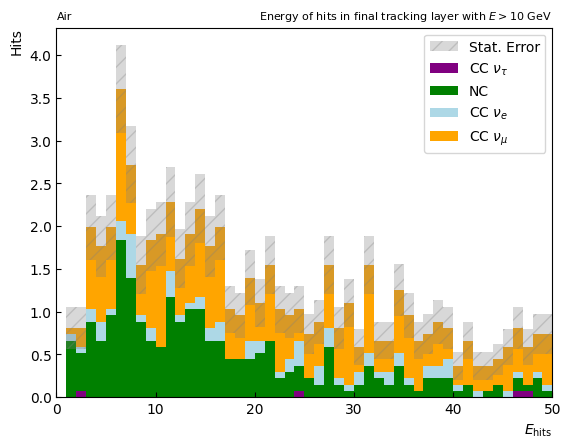

In [524]:
plot_stacked_hist(datasets_10GeV_thresh, "E", (2000, 0, 2000),
                  scale_factor=air_sf, xlabel=r"$E_\text{hits}$", ylabel="Hits",
                  title_left="Air", title_right="Energy of hits in final tracking layer with $E > 10$ GeV",
                  saveas="AirDV-HitEnergyAbove10GeVStation5.svg",
                  xrange=[0, 50]

                  )

In [471]:
def select_events_with_n_hits(dataset, nhits):
    mask = []
    for i, event in enumerate(dataset):
        val = len(event["x"][dataset.hits_mask[i]])

        m = None
        if val == nhits:
            mask.append(True)
            m = True
        else:
            mask.append(False)
            m = False
    
        # print(val, m)
    dataset.events = deepcopy(dataset.events[mask])
    
    
    for i, event in enumerate(dataset):
        val = len(event['x'][dataset.hits_mask[i]])
        
        print(val, event['x'][dataset.hits_mask[i]])
        
    return dataset

In [474]:
datasets_2Hits = deepcopy(datasets)
# datasets_2Hits = [select_events_with_n_hits(ds, 2) for ds in datasets_2Hits]

for i in range(len(datasets_2Hits)):
    mask = compute_masks(datasets_2Hits[i].events, energy_threshold=10, nhits=2)
    datasets_2Hits[i].hits_mask = mask    
    
# for ds in datasets_2Hits:
#     for i, event in enumerate(ds):
#         val = len(event['x'][ds.hits_mask[i]])
        
#         print(val, event['x'][ds.hits_mask[i]])

Neutral Current 303
Charged Current Muon 918
Charged Current Electron 213
Charged Current Tau 12


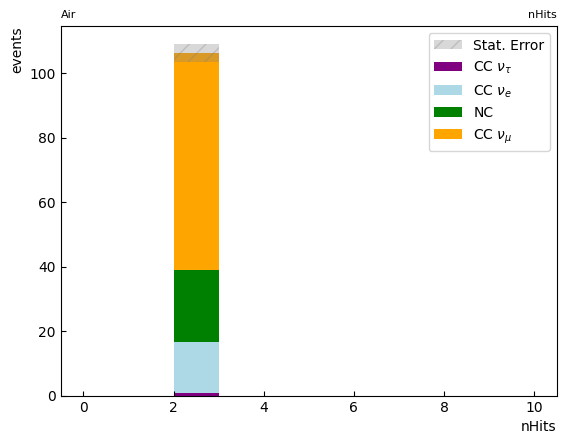

In [475]:
plot_stacked_hist(datasets_2Hits, "x", (10, 0, 10), function=len,
                  scale_factor=air_sf, xlabel=r"nHits", 
                  title_left="Air", title_right="nHits",
                  saveas="AirDV-nHits-MiniLLPSearch.svg"
                  )

Neutral Current 303
Charged Current Muon 918
Charged Current Electron 213
Charged Current Tau 12


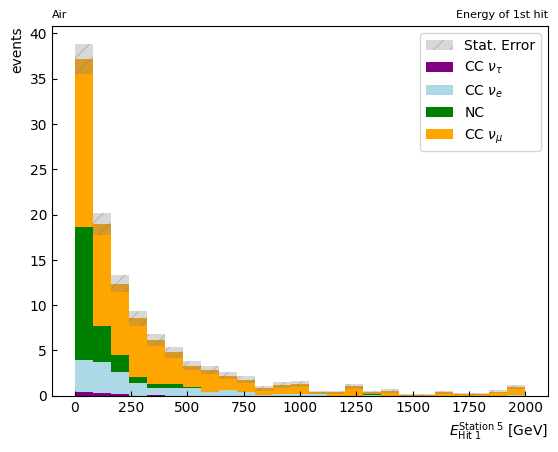

In [476]:
plot_stacked_hist(datasets_2Hits, "E", (25, 0, 2000), function=max,
                  scale_factor=air_sf, xlabel=r"$E_\text{Hit 1}^\text{Station 5}$ [GeV]", 
                  title_left="Air", title_right="Energy of 1st hit",
                  saveas="AirDV-FirstHitEnergy-MiniLLPSearch.svg"
                  )

Neutral Current 303
Charged Current Muon 918
Charged Current Electron 213
Charged Current Tau 12


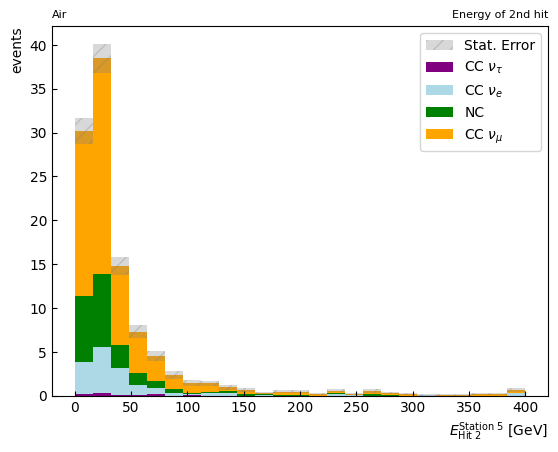

In [477]:
plot_stacked_hist(datasets_2Hits, "E", (25, 0, 400), function=min,
                  scale_factor=air_sf, xlabel=r"$E_\text{Hit 2}^\text{Station 5}$ [GeV]", 
                  title_left="Air", title_right="Energy of 2nd hit",
                  saveas="AirDV-SecondHitEnergy-MiniLLPSearch.svg"
                  )

Neutral Current 2334
Charged Current Muon 5811
Charged Current Electron 1199
Charged Current Tau 56


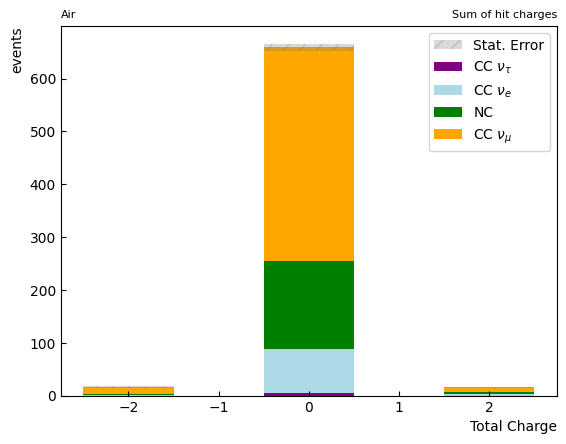

In [478]:
plot_stacked_hist(datasets_2Hits, "charge", (5, -2.5, 2.5), function=sum, fill_zero=True,
                  scale_factor=air_sf, xlabel=r"Total Charge", 
                  title_left="Air", title_right="Sum of hit charges",
                  saveas="AirDV-ChargeSum-MiniLLPSearch.svg"
                  )

Neutral Current 2334
Charged Current Muon 5811
Charged Current Electron 1199
Charged Current Tau 56


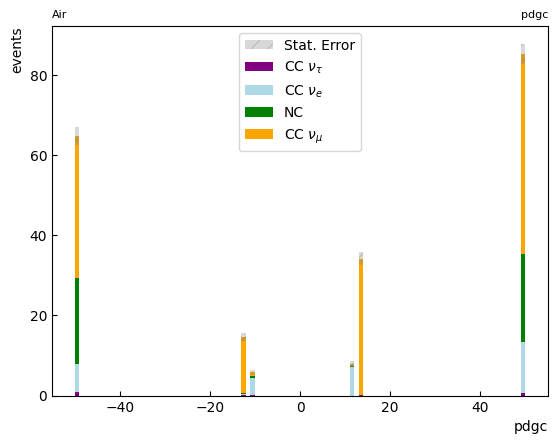

In [479]:
plot_stacked_hist(datasets_2Hits, "pdgc", (100, -50, 50), fill_zero=True,
                  scale_factor=air_sf, xlabel=r"pdgc", 
                  title_left="Air", title_right="pdgc"
                  )

Neutral Current 303
Charged Current Muon 918
Charged Current Electron 213
Charged Current Tau 12


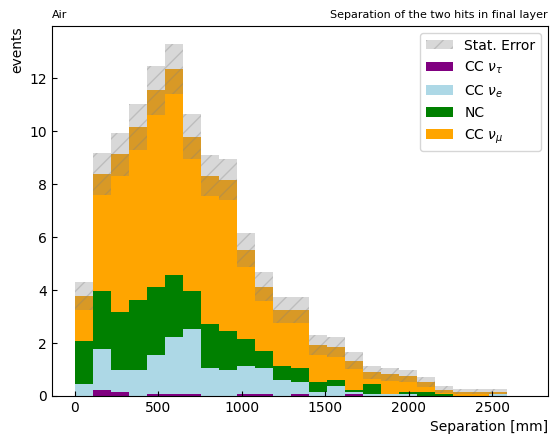

In [480]:
def compute_separation(event, mask):
    x1 = event['x'][mask][0]
    x2 = event['x'][mask][1]
    y1 = event['y'][mask][0]
    y2 = event['y'][mask][1]
    # print(x1)
    return np.sqrt((x1 - x2)**2 + (y1 - y2)**2)

plot_stacked_hist(datasets_2Hits, None, (25, 0, 2700), fill_zero=True, function=compute_separation,
                  scale_factor=air_sf, xlabel=r"Separation [mm]", 
                  title_left="Air", title_right="Separation of the two hits in final layer",
                  saveas="AirDV-HitSeparation-MiniLLPSearch.svg"
                  )

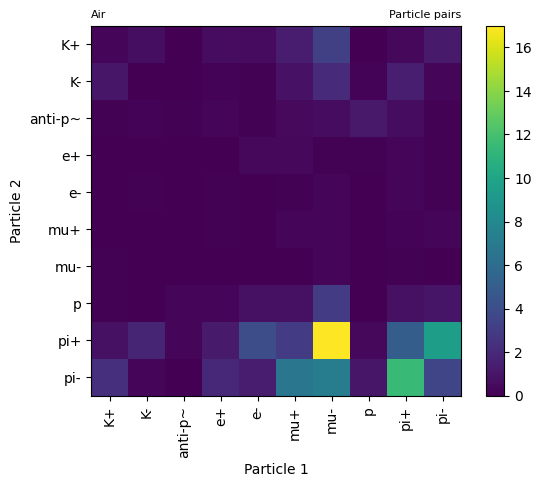

In [481]:
pdgc_pairs = []
for ds in datasets_2Hits:
    for i, event in enumerate(ds):
        p = get_name_from_pdgc(event['pdgc'][ds.hits_mask[i]])
        pdgc_pairs.append(p)
    
from collections import Counter

# Flatten the list of pairs and count occurrences
flattened_pairs = [pair for sublist in pdgc_pairs for pair in sublist]
pair_counts = Counter(zip(flattened_pairs[::2], flattened_pairs[1::2]))

# Extract unique particles and count matrix
particles = list(set(flattened_pairs))
particles.sort()
count_matrix = np.zeros((len(particles), len(particles)))

for (p1, p2), count in pair_counts.items():
    i, j = particles.index(p1), particles.index(p2)
    count_matrix[i, j] = count

# Plotting the 2D histogram
fig, ax = plt.subplots()
cax = ax.matshow(count_matrix*air_sf, cmap='viridis')

# Set axis labels
ax.set_xticks(np.arange(len(particles)))
ax.set_yticks(np.arange(len(particles)))
ax.set_xticklabels(particles, rotation=90)
ax.set_yticklabels(particles)


ax.tick_params(axis='x', bottom=True, top=False, labelbottom=True, labeltop=False)

# Add color bar
plt.colorbar(cax)

ax.set_xlabel('Particle 1')
ax.set_ylabel('Particle 2')
ax.set_title('Air', loc="left", fontsize=8)
ax.set_title('Particle pairs', loc="right", fontsize=8)

plt.savefig("AirDV-ParticlePDGPairs-MiniLLPSearch.svg")
plt.show()

# for pair in pdgc_pairs:
#     print(pair)
    
#* Note: 465 mu- vs 199 mu+
